# Model Validation Notebook

Load a saved model from `data/saved_models/` and run validation.

In [ ]:
import pandas as pd
import torch
import pickle
import numpy as np
import matplotlib.pyplot as plt
import glob
from collections import Counter
from pathlib import Path

# Imports from our project
from src.utils.paths import PROJECT_ROOT, get_data_folder
from src.utils.ontology_utils import load_ontology
from src.train.model import SimpleNN, WideNN
from src.train.loss import MarginalizationLoss

## 1. Select and Load Model

In [ ]:
# List all available models
save_dir = PROJECT_ROOT / "data" / "saved_models"
model_files = sorted(
    glob.glob(str(save_dir / "blood_cell_model_*.pt")) +
    glob.glob(str(save_dir / "model_*.pt"))
)

print("Available models:")
for i, model_file in enumerate(model_files):
    model_name = model_file.split('/')[-1]
    print(f"  [{i}] {model_name}")

if not model_files:
    print("\nNo saved models found in data/saved_models/")
    print("   Please train a model first using train.ipynb")
else:
    ''' Note: Anything before blood_cell_model_2025-12-23 is deprecated'''
    model_index = -4
    model_path = model_files[model_index]
    print(f"\nSelected: {model_path.split('/')[-1]}")

In [ ]:
# Load checkpoint
print(f"Loading checkpoint from: {model_path}")
checkpoint = torch.load(model_path, map_location='cpu')

# Print checkpoint info
saved_model_class = checkpoint.get('model_class', 'SimpleNN')
print("\n" + "="*80)
print("CHECKPOINT INFORMATION")
print("="*80)
print(f"Model architecture: {saved_model_class}()")
print(f"Training epochs: {checkpoint['epoch']}")
print(f"Total batches processed: {checkpoint['total_batches_processed']:,}")
print(f"Final training loss: {checkpoint['batch_loss_history'][-1]:.4f}")
print(f"Trained on {checkpoint['num_gpus']} GPU(s)")
print(f"Total training time: {sum(checkpoint['epoch_times'])/3600:.2f} hours")
print("="*80 + "\n")

# Extract key variables
DATE = checkpoint['date_preprocessed']
ROOT_CL_ID = checkpoint.get('root_cl_id', 'CL:0000988')  # fallback for old checkpoints
input_dim = checkpoint['input_dim']
output_dim = checkpoint['output_dim']

print(f"Preprocessed date: {DATE}")
print(f"Root CL ID: {ROOT_CL_ID}")

## 2. Load Preprocessed Data

In [ ]:
# Load data from the same date as the model was trained on
PROCESSED_DATA_DIR = get_data_folder(DATE, ROOT_CL_ID)
print(f"Loading data from: {PROCESSED_DATA_DIR} for date {DATE}")

# Load the ontology
cl = load_ontology()

# Load DataFrames
marginalization_df = pd.read_csv(PROCESSED_DATA_DIR / f"{DATE}_marginalization_df.csv", index_col=0)
parent_child_df = pd.read_csv(PROCESSED_DATA_DIR / f"{DATE}_parent_child_df.csv", index_col=0)
exclusion_df = pd.read_csv(PROCESSED_DATA_DIR / f"{DATE}_exclusion_df.csv", index_col=0)

# Load mapping_dict
mapping_dict_df = pd.read_csv(PROCESSED_DATA_DIR / f"{DATE}_mapping_dict_df.csv", index_col=0)
mapping_dict = pd.Series(mapping_dict_df.iloc[:, 0].values, index=mapping_dict_df.index).to_dict()

# Load leaf and internal values
with open(PROCESSED_DATA_DIR / f"{DATE}_leaf_values.pkl", "rb") as fp:
    leaf_values = pickle.load(fp)
with open(PROCESSED_DATA_DIR / f"{DATE}_internal_values.pkl", "rb") as fp:
    internal_values = pickle.load(fp)

print("\nAll data artifacts loaded successfully.")
print(f"Loaded {len(mapping_dict)} cell types.")
print(f"  - {len(leaf_values)} leaf nodes")
print(f"  - {len(internal_values)} internal nodes")

## 3. Initialize Model and Load Weights

In [ ]:
# Setup device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create model architecture using checkpoint metadata
saved_model_class = checkpoint.get('model_class', 'SimpleNN')
ModelClass = {"SimpleNN": SimpleNN, "WideNN": WideNN}[saved_model_class]
validation_model = ModelClass(input_dim=input_dim, output_dim=output_dim)

# Handle DataParallel if model was trained on multiple GPUs
num_gpus = torch.cuda.device_count()
if num_gpus > 1:
    validation_model = torch.nn.DataParallel(validation_model)
    validation_model.module.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded DataParallel model ({num_gpus} GPUs available)")
else:
    validation_model.load_state_dict(checkpoint['model_state_dict'])
    print("Loaded model (single GPU)")

validation_model = validation_model.to(device)
validation_model.eval()

print(f"Model loaded successfully: {saved_model_class}({input_dim} -> {output_dim})")

# Initialize loss function
loss_fn = MarginalizationLoss(
    marginalization_df=marginalization_df,
    parent_child_df=parent_child_df,
    exclusion_df=exclusion_df,
    leaf_values=leaf_values,
    internal_values=internal_values,
    mapping_dict=mapping_dict,
    device=device
)
print("Loss function initialized.")

## 4. Create Validation DataLoader

In [20]:
import cellxgene_census
import tiledbsoma as soma
from tiledbsoma_ml import ExperimentDataset, experiment_dataloader

# Get all cell types
all_cell_values = list(mapping_dict.keys())

# Load gene list from BioMart
print("Loading protein-coding genes from BioMart...")
biomart_path = PROJECT_ROOT / "hpc_workaround/data/mart_export.txt"
biomart = pd.read_csv(biomart_path)
coding_only = biomart[biomart['Gene type'] == 'protein_coding']
gene_list = coding_only['Gene stable ID'].tolist()
print(f"Loaded {len(gene_list)} protein-coding genes")

# Create filter strings
var_value_filter = f"feature_id in {gene_list}"
obs_value_filter = f'assay == "10x 3\' v3" and is_primary_data == True and cell_type_ontology_term_id in {all_cell_values}'

# Open SOMA database
soma_uri = "/scratch/sigbio_project_root/sigbio_project25/jingqiao/mccell-single/soma_db_homo_sapiens"
print(f"\nOpening local SOMA database at: {soma_uri}")
experiment = soma.open(soma_uri, mode="r")

# Create validation dataset
with experiment.axis_query(
    measurement_name="RNA",
    obs_query=soma.AxisQuery(value_filter=obs_value_filter),
    var_query=soma.AxisQuery(value_filter=var_value_filter),
) as query:
    experiment_dataset = ExperimentDataset(
        query,
        obs_column_names=["cell_type_ontology_term_id"],
        layer_name="raw",
        batch_size=256,
        shuffle=True,
        seed=999  # Different seed for validation
    )
    
    # Use only validation split (20%)
    _, val_dataset = experiment_dataset.random_split(0.8, 0.2, seed=42)
    
    print(f'\nValidation set size: {len(val_dataset)}')
    print(f'Validation dataset shape: {val_dataset.shape}')

val_dataloader = experiment_dataloader(val_dataset)
print("Validation dataloader ready.")

Loading protein-coding genes from BioMart...
Loaded 23262 protein-coding genes

Opening local SOMA database at: /scratch/sigbio_project_root/sigbio_project25/jingqiao/mccell-single/soma_db_homo_sapiens

Validation set size: 4917
Validation dataset shape: (4917, 20060)
Validation dataloader ready.


In [21]:
def evaluate_leaf_predictions(model_output, true_labels):
    """
    Evaluate leaf node predictions.
    
    Args:
        model_output: Raw logits from model (batch_size, num_leaf_classes)
        true_labels: True leaf indices (batch_size,)
    
    Returns:
        predictions: Predicted leaf indices (batch_size,)
    """
    predictions = torch.argmax(model_output, dim=1)
    return predictions


def evaluate_internal_predictions(model_output, true_labels, marginalization_tensor, 
                                  internal_idx_to_position, threshold=0.5):
    """
    Evaluate internal node predictions using marginalization.
    
    Args:
        model_output: Raw logits from model (batch_size, num_leaf_classes)
        true_labels: True internal node indices (batch_size,)
        marginalization_tensor: Tensor for marginalization (num_internal, num_leaf)
        internal_idx_to_position: Dict mapping internal node index to position in marginalization_tensor
        threshold: Probability threshold for success (default 0.5)
    
    Returns:
        predictions: Binary predictions (1=success, 0=fail) (batch_size,)
    """
    # Apply softmax to get leaf probabilities
    leaf_probs = torch.softmax(model_output, dim=1)  # (batch_size, num_leaf)
    
    # Marginalize: sum leaf probs to get internal probs
    internal_probs = torch.matmul(leaf_probs, marginalization_tensor.T)  # (batch_size, num_internal)
    
    # For each sample, check if P(true_internal_node) >= threshold
    predictions = []
    for sample_idx, true_internal_idx in enumerate(true_labels):
        internal_position = internal_idx_to_position[true_internal_idx.item()]
        pred_prob = internal_probs[sample_idx, internal_position].item()
        predictions.append(1 if pred_prob >= threshold else 0)
    
    return torch.tensor(predictions, device=model_output.device)


print("Evaluation functions defined.")

Evaluation functions defined.


In [22]:
print("="*80)
print("RUNNING VALIDATION (LEAF + INTERNAL NODES)")
print("="*80)
print("Processing 50 batches (~12,800 cells)\n")

# ============================================================================
# Setup for internal node evaluation
# ============================================================================

INTERNAL_THRESHOLD = 0.5
VAL_BATCHES = 1000  # Sample 50 batches from 4,917 total batches

# Prepare marginalization tensor
marginalization_tensor = torch.FloatTensor(
    marginalization_df.loc[internal_values, leaf_values].values
).to(device)

# Find valid internal nodes (those with at least one leaf descendant)
valid_internal_nodes = []
for cl_id in internal_values:
    if cl_id in marginalization_df.index:
        row_sum = marginalization_df.loc[cl_id, leaf_values].sum()
        if row_sum > 0:
            valid_internal_nodes.append(cl_id)

valid_internal_indices_set = {mapping_dict[cid] for cid in valid_internal_nodes}
leaf_indices_set = {mapping_dict[cid] for cid in leaf_values}
internal_indices_set = {mapping_dict[cid] for cid in internal_values}
internal_idx_to_position = {mapping_dict[cid]: i for i, cid in enumerate(internal_values)}

print(f"Valid internal nodes (with leaf descendants): {len(valid_internal_nodes)} / {len(internal_values)}")
print(f"Leaf nodes: {len(leaf_values)}")
print(f"Internal threshold: {INTERNAL_THRESHOLD}\n")

# ============================================================================
# Run validation
# ============================================================================

val_total_losses = []
val_leaf_losses = []
val_parent_losses = []

# Leaf predictions: store actual predicted class indices
leaf_all_predictions = []
leaf_all_labels = []

# Internal predictions: store binary success (1) or fail (0)
internal_all_predictions = []
internal_all_labels = []

total_samples = 0
leaf_samples = 0
internal_samples = 0
skipped_internal_samples = 0

with torch.no_grad():
    for i, (X_batch, obs_batch) in enumerate(val_dataloader):
        if i >= VAL_BATCHES:
            break
            
        # Data preparation
        X_batch = torch.from_numpy(X_batch).float()
        X_batch = torch.log1p(X_batch)
        X_batch = X_batch.to(device)

        label_strings = obs_batch["cell_type_ontology_term_id"]
        y_batch = torch.tensor([mapping_dict[term] for term in label_strings],
                              device=device, dtype=torch.long)

        total_samples += len(y_batch)

        # ========================================================================
        # Process LEAF-labeled samples
        # ========================================================================
        is_leaf = torch.tensor([y.item() in leaf_indices_set for y in y_batch], device=device)

        if is_leaf.sum() > 0:
            X_batch_leaf = X_batch[is_leaf]
            y_batch_leaf = y_batch[is_leaf]
            leaf_samples += len(y_batch_leaf)

            # Forward pass
            outputs_leaf = validation_model(X_batch_leaf)
            
            # Calculate loss
            total_loss, loss_leafs, loss_parents = loss_fn(outputs_leaf, y_batch_leaf)
            val_total_losses.append(total_loss.item())
            val_leaf_losses.append(loss_leafs.item())
            val_parent_losses.append(loss_parents.item())

            # Evaluate predictions
            predictions = evaluate_leaf_predictions(outputs_leaf, y_batch_leaf)
            leaf_all_predictions.extend(predictions.cpu().numpy())
            leaf_all_labels.extend(y_batch_leaf.cpu().numpy())

        # ========================================================================
        # Process INTERNAL-labeled samples (only evaluable ones)
        # ========================================================================
        is_internal_valid = torch.tensor([y.item() in valid_internal_indices_set for y in y_batch], 
                                         device=device)

        if is_internal_valid.sum() > 0:
            X_batch_internal = X_batch[is_internal_valid]
            y_batch_internal = y_batch[is_internal_valid]
            internal_samples += len(y_batch_internal)

            # Forward pass
            outputs_internal = validation_model(X_batch_internal)
            
            # Evaluate predictions (returns binary: 1=success, 0=fail)
            predictions = evaluate_internal_predictions(
                outputs_internal, 
                y_batch_internal, 
                marginalization_tensor,
                internal_idx_to_position,
                threshold=INTERNAL_THRESHOLD
            )
            
            internal_all_predictions.extend(predictions.cpu().numpy())
            internal_all_labels.extend(y_batch_internal.cpu().numpy())

        # Count skipped internal samples (non-evaluable)
        is_internal_invalid = torch.tensor([y.item() in internal_indices_set and 
                                           y.item() not in valid_internal_indices_set 
                                           for y in y_batch], device=device)
        skipped_internal_samples += is_internal_invalid.sum().item()

# Convert to numpy arrays
leaf_all_predictions = np.array(leaf_all_predictions)
leaf_all_labels = np.array(leaf_all_labels)
internal_all_predictions = np.array(internal_all_predictions)
internal_all_labels = np.array(internal_all_labels)

# Calculate metrics
avg_val_loss = np.mean(val_total_losses) if val_total_losses else 0
avg_leaf_loss = np.mean(val_leaf_losses) if val_leaf_losses else 0
avg_parent_loss = np.mean(val_parent_losses) if val_parent_losses else 0

leaf_accuracy = (leaf_all_predictions == leaf_all_labels).mean() if len(leaf_all_labels) > 0 else 0
internal_accuracy = internal_all_predictions.mean() if len(internal_all_predictions) > 0 else 0

print("\n" + "="*80)
print("VALIDATION RESULTS")
print("="*80)
print(f"Batches processed: {VAL_BATCHES} / 4,917 total validation batches")
print(f"Total samples processed: {total_samples:,}")
print(f"  Leaf-labeled samples:              {leaf_samples:,}")
print(f"  Internal-labeled (evaluable):      {internal_samples:,}")
print(f"  Internal-labeled (non-evaluable):  {skipped_internal_samples:,}")
print(f"\nLoss Metrics (Leaf samples only):")
print(f"  Average Total Loss:   {avg_val_loss:.4f}")
print(f"  Average Leaf Loss:    {avg_leaf_loss:.4f}")
print(f"  Average Parent Loss:  {avg_parent_loss:.4f}")
print(f"\nAccuracy Metrics:")
print(f"  Leaf Accuracy:        {leaf_accuracy*100:.2f}%")
print(f"  Internal Accuracy:    {internal_accuracy*100:.2f}%")
print("="*80 + "\n")

RUNNING VALIDATION (LEAF + INTERNAL NODES)
Processing 50 batches (~12,800 cells)

Valid internal nodes (with leaf descendants): 35 / 35
Leaf nodes: 45
Internal threshold: 0.5


VALIDATION RESULTS
Batches processed: 1000 / 4,917 total validation batches
Total samples processed: 256,000
  Leaf-labeled samples:              68,007
  Internal-labeled (evaluable):      187,993
  Internal-labeled (non-evaluable):  0

Loss Metrics (Leaf samples only):
  Average Total Loss:   43.6883
  Average Leaf Loss:    43.3195
  Average Parent Loss:  0.3688

Accuracy Metrics:
  Leaf Accuracy:        0.94%
  Internal Accuracy:    5.83%



In [23]:
# Create reverse mapping (index -> CL ID)
reverse_mapping = {v: k for k, v in mapping_dict.items()}

# Per-class accuracy for LEAF nodes
unique_labels = np.unique(leaf_all_labels)
per_class_accuracy = {}

print("\n" + "="*80)
print("PER-CLASS ACCURACY (LEAF NODES)")
print("="*80)
print(f"{'Cell Type':<50} {'Count':<8} {'Accuracy':<10}")
print("-" * 80)

for label_idx in sorted(unique_labels):
    mask = leaf_all_labels == label_idx
    class_acc = (leaf_all_predictions[mask] == label_idx).mean()
    count = mask.sum()
    
    cl_id = reverse_mapping[label_idx]
    cell_name = cl[cl_id].name
    per_class_accuracy[cl_id] = class_acc
    
    print(f"{cell_name:<50} {count:<8} {class_acc*100:>6.2f}%")

print("="*80 + "\n")


PER-CLASS ACCURACY (LEAF NODES)
Cell Type                                          Count    Accuracy  
--------------------------------------------------------------------------------
erythroid progenitor cell                          317        0.00%
common lymphoid progenitor                         357        0.00%
Kupffer cell                                       178        0.00%
mast cell                                          2492       0.00%
erythrocyte                                        1020       0.00%
platelet                                           637        0.00%
alveolar macrophage                                4948       0.00%
neutrophil                                         4844       0.00%
plasmacytoid dendritic cell                        448        0.00%
memory B cell                                      834        0.00%
naive B cell                                       1840       0.00%
gamma-delta T cell                                 1015       0.00%

In [24]:
# Per-class accuracy for INTERNAL nodes
from collections import defaultdict

per_node_stats = defaultdict(lambda: {'correct': 0, 'total': 0})

for true_idx, pred_binary in zip(internal_all_labels, internal_all_predictions):
    per_node_stats[true_idx]['total'] += 1
    if pred_binary == 1:  # Success
        per_node_stats[true_idx]['correct'] += 1

print("\n" + "="*80)
print("PER-CLASS ACCURACY (INTERNAL NODES)")
print("="*80)
print(f"{'Cell Type':<50} {'Count':<10} {'Accuracy':<10}")
print("-" * 80)

# Sort by accuracy
node_accuracies = []
for internal_idx, stats in per_node_stats.items():
    cl_id = reverse_mapping[internal_idx]
    cell_name = cl[cl_id].name
    node_acc = stats['correct'] / stats['total'] if stats['total'] > 0 else 0
    node_accuracies.append((cell_name, stats['total'], node_acc))

node_accuracies.sort(key=lambda x: x[2], reverse=True)

for cell_name, count, acc in node_accuracies:
    print(f"{cell_name:<50} {count:<10} {acc*100:>6.2f}%")

print("="*80 + "\n")


PER-CLASS ACCURACY (INTERNAL NODES)
Cell Type                                          Count      Accuracy  
--------------------------------------------------------------------------------
myeloid cell                                       6218       100.00%
leukocyte                                          2523       100.00%
mononuclear phagocyte                              1620       100.00%
hematopoietic cell                                 594        100.00%
monocyte                                           15292        0.00%
macrophage                                         22920        0.00%
hematopoietic precursor cell                       16545        0.00%
T cell                                             24720        0.00%
CD4-positive, alpha-beta T cell                    8258         0.00%
microglial cell                                    12144        0.00%
central nervous system macrophage                  8173         0.00%
B cell                                 

## 10. Training History

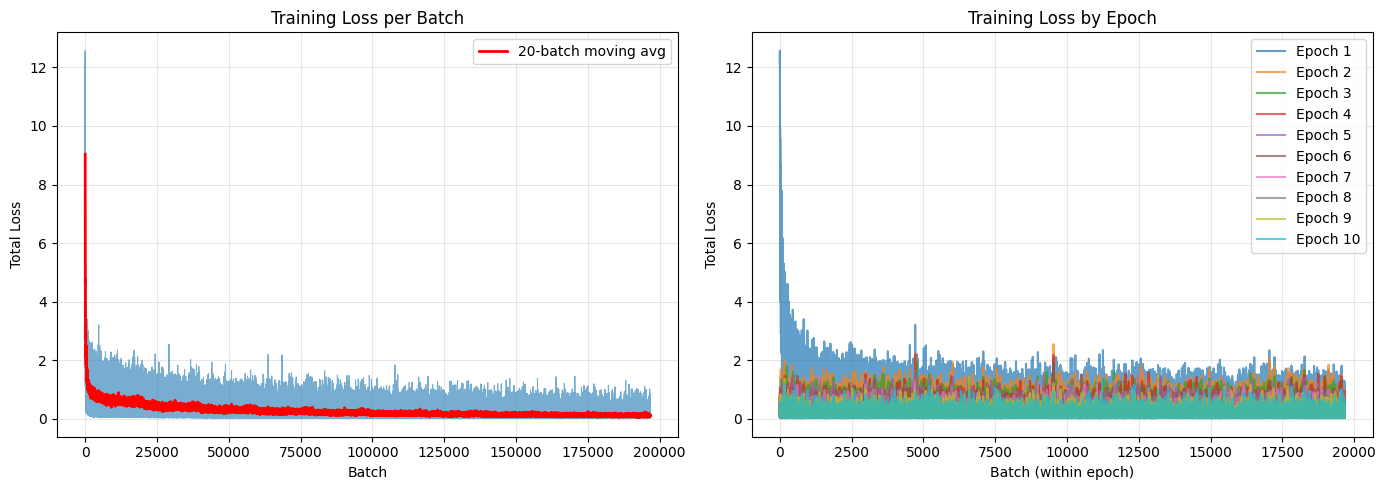


Training Summary:
  Initial loss: 12.1550
  Final loss: 0.0225
  Loss reduction: 99.8%


In [25]:
# Plot training loss from checkpoint
batch_loss_history = checkpoint['batch_loss_history']
num_epochs = checkpoint['epoch']
batches_per_epoch = len(batch_loss_history) // num_epochs

plt.figure(figsize=(14, 5))

# Overall training loss
plt.subplot(1, 2, 1)
plt.plot(batch_loss_history, alpha=0.6, linewidth=0.8)
plt.xlabel('Batch')
plt.ylabel('Total Loss')
plt.title('Training Loss per Batch')
plt.grid(True, alpha=0.3)

# Moving average
window_size = 20
if len(batch_loss_history) >= window_size:
    moving_avg = np.convolve(batch_loss_history, np.ones(window_size)/window_size, mode='valid')
    plt.plot(range(window_size-1, len(batch_loss_history)), moving_avg, 
             color='red', linewidth=2, label=f'{window_size}-batch moving avg')
    plt.legend()

# Loss by epoch
plt.subplot(1, 2, 2)
if num_epochs > 1:
    epoch_losses = [batch_loss_history[i*batches_per_epoch:(i+1)*batches_per_epoch] 
                   for i in range(num_epochs)]
    for i, losses in enumerate(epoch_losses):
        plt.plot(losses, label=f'Epoch {i+1}', alpha=0.7)
    plt.xlabel('Batch (within epoch)')
    plt.ylabel('Total Loss')
    plt.title('Training Loss by Epoch')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTraining Summary:")
print(f"  Initial loss: {batch_loss_history[0]:.4f}")
print(f"  Final loss: {batch_loss_history[-1]:.4f}")
print(f"  Loss reduction: {(1 - batch_loss_history[-1]/batch_loss_history[0])*100:.1f}%")

## 9. F1 Score Analysis

In [26]:
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

print("\n" + "="*80)
print("F1 SCORE ANALYSIS")
print("="*80)

# ============================================================================
# LEAF NODE F1 SCORES
# ============================================================================

print("\n" + "-"*80)
print("LEAF NODES")
print("-"*80)

# Calculate different F1 averaging methods
micro_f1_leaf = f1_score(leaf_all_labels, leaf_all_predictions, average='micro')
macro_f1_leaf = f1_score(leaf_all_labels, leaf_all_predictions, average='macro')
weighted_f1_leaf = f1_score(leaf_all_labels, leaf_all_predictions, average='weighted')

# Per-class F1, Precision, Recall
per_class_f1_leaf = f1_score(leaf_all_labels, leaf_all_predictions, average=None)
per_class_precision_leaf = precision_score(leaf_all_labels, leaf_all_predictions, average=None, zero_division=0)
per_class_recall_leaf = recall_score(leaf_all_labels, leaf_all_predictions, average=None, zero_division=0)

print(f"\n{'Metric':<20} {'Value':<10}")
print("-" * 40)
print(f"{'Accuracy':<20} {leaf_accuracy*100:>6.2f}%")
print(f"{'Micro-F1':<20} {micro_f1_leaf*100:>6.2f}%")
print(f"{'Macro-F1':<20} {macro_f1_leaf*100:>6.2f}%")
print(f"{'Weighted-F1':<20} {weighted_f1_leaf*100:>6.2f}%")

print(f"\n{'Verification:':<20}")
print(f"  Micro-F1 == Accuracy? {np.isclose(micro_f1_leaf, leaf_accuracy)}")

# ============================================================================
# INTERNAL NODE F1 SCORES
# ============================================================================

print("\n" + "-"*80)
print("INTERNAL NODES (Binary Classification: Success vs Fail)")
print("-"*80)

# For internal nodes, we have binary predictions (1=success, 0=fail)
# We want to calculate F1 for the "success" class (label=1)

# Create binary labels: all ground truth is "should succeed" = 1
internal_binary_labels = np.ones_like(internal_all_predictions)

# Calculate F1 for the positive class (success)
f1_internal = f1_score(internal_binary_labels, internal_all_predictions, pos_label=1)
precision_internal = precision_score(internal_binary_labels, internal_all_predictions, pos_label=1, zero_division=0)
recall_internal = recall_score(internal_binary_labels, internal_all_predictions, pos_label=1, zero_division=0)

print(f"\n{'Metric':<20} {'Value':<10}")
print("-" * 40)
print(f"{'Accuracy':<20} {internal_accuracy*100:>6.2f}%")
print(f"{'Precision':<20} {precision_internal*100:>6.2f}%")
print(f"{'Recall':<20} {recall_internal*100:>6.2f}%")
print(f"{'F1 Score':<20} {f1_internal*100:>6.2f}%")

print(f"\n{'Note:':<20}")
print(f"  For internal nodes, Accuracy = Recall = F1")
print(f"  (All true labels are 'success', so precision is N/A)")

# ============================================================================
# PER-CLASS METRICS
# ============================================================================

print("\n" + "="*80)
print("PER-CLASS METRICS (LEAF NODES)")
print("="*80)
print(f"{'Cell Type':<50} {'Count':<8} {'Precision':<12} {'Recall':<10} {'F1 Score':<10}")
print("-" * 110)

# Sort by F1 score (descending)
class_metrics = []
unique_leaf_labels = np.unique(leaf_all_labels)
for i, label_idx in enumerate(sorted(unique_leaf_labels)):
    cl_id = reverse_mapping[label_idx]
    cell_name = cl[cl_id].name
    count = (leaf_all_labels == label_idx).sum()
    
    class_metrics.append({
        'name': cell_name,
        'count': count,
        'precision': per_class_precision_leaf[i],
        'recall': per_class_recall_leaf[i],
        'f1': per_class_f1_leaf[i]
    })

# Sort by F1 score
class_metrics_sorted = sorted(class_metrics, key=lambda x: x['f1'], reverse=True)

for m in class_metrics_sorted:
    print(f"{m['name']:<50} {m['count']:<8} {m['precision']*100:>6.2f}%      {m['recall']*100:>6.2f}%    {m['f1']*100:>6.2f}%")

print("="*80)

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"\nLEAF NODES:")
print(f"  Samples:      {len(leaf_all_labels):,}")
print(f"  Accuracy:     {leaf_accuracy*100:.2f}%")
print(f"  Micro-F1:     {micro_f1_leaf*100:.2f}%")
print(f"  Macro-F1:     {macro_f1_leaf*100:.2f}%")
print(f"  Weighted-F1:  {weighted_f1_leaf*100:.2f}%")

print(f"\nINTERNAL NODES:")
print(f"  Samples:      {len(internal_all_labels):,}")
print(f"  Accuracy:     {internal_accuracy*100:.2f}%")
print(f"  F1 Score:     {f1_internal*100:.2f}%")

print(f"\nOVERALL:")
print(f"  Total samples evaluated: {len(leaf_all_labels) + len(internal_all_labels):,}")
print(f"  Leaf samples:            {len(leaf_all_labels):,} ({len(leaf_all_labels)/(len(leaf_all_labels)+len(internal_all_labels))*100:.1f}%)")
print(f"  Internal samples:        {len(internal_all_labels):,} ({len(internal_all_labels)/(len(leaf_all_labels)+len(internal_all_labels))*100:.1f}%)")
print("="*80 + "\n")


F1 SCORE ANALYSIS

--------------------------------------------------------------------------------
LEAF NODES
--------------------------------------------------------------------------------

Metric               Value     
----------------------------------------
Accuracy               0.94%
Micro-F1               0.94%
Macro-F1               0.04%
Weighted-F1            0.02%

Verification:       
  Micro-F1 == Accuracy? True

--------------------------------------------------------------------------------
INTERNAL NODES (Binary Classification: Success vs Fail)
--------------------------------------------------------------------------------

Metric               Value     
----------------------------------------
Accuracy               5.83%
Precision            100.00%
Recall                 5.83%
F1 Score              11.01%

Note:               
  For internal nodes, Accuracy = Recall = F1
  (All true labels are 'success', so precision is N/A)

PER-CLASS METRICS (LEAF NODES)
Cel